# Data audit

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)
RANDOM_STATE = 42

DATA_PATH = '../steam_reviews 1.csv'
df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()

In [19]:
print("--- Shape ---")
print(df.shape)

print("\n--- Dtypes ---")
print(df.dtypes)

print("\n--- Nulls per column ---")
print(df.isna().sum())      

print("\n--- Title counts ---")                        
print(df["title"].value_counts())      

print("\n--- Date span per game ---")             
print(df.groupby("title")["date_posted"].agg(["min", "max"]))

print("\n--- Hour played description ---")
print(df["hour_played"].describe())        

print("\n--- Early-access review share ---")   
print(df["is_early_access_review"].mean())          


--- Shape ---
(14617, 8)

--- Dtypes ---
date_posted                 str
funny                     int64
helpful                   int64
hour_played               int64
is_early_access_review     bool
recommendation              str
review                      str
title                       str
dtype: object

--- Nulls per column ---
date_posted               0
funny                     0
helpful                   0
hour_played               0
is_early_access_review    0
recommendation            0
review                    7
title                     0
dtype: int64

--- Title counts ---
title
PLAYERUNKNOWN'S BATTLEGROUNDS                  2539
Rust                                           2291
Grand Theft Auto V                             2174
Rocket League®                                 1773
Dead by Daylight                               1034
The Elder Scrolls V: Skyrim Special Edition     977
MONSTER HUNTER: WORLD                           774
ASTRONEER                         

**FINDING - review has 7 missing values** Dataset also has 23 games instead of the 10 games claimed in the dataset information, 5 of the games have fewer than 10 reviews

## Target balance

In [11]:
print(df['recommendation'].value_counts())
print()
print(df['recommendation'].value_counts(normalize=True).round(3))

recommendation
Recommended        10394
Not Recommended     4223
Name: count, dtype: int64

recommendation
Recommended        0.711
Not Recommended    0.289
Name: proportion, dtype: float64


**Takeaway:** 71% Recommended / 29% Not Recommended — moderately imbalanced.

In [21]:
print("\nearly access share:", round(df["is_early_access_review"].mean(), 3))
print("under 5 chars:", (df["review"].str.len() < 5).sum())


early access share: 0.29
under 5 chars: 338


# Cleaning - AI used here

In [12]:
df_clean = df.copy()
n0 = len(df_clean)

df_clean['date_posted'] = pd.to_datetime(df_clean['date_posted'], errors='coerce')
print('Unparseable dates:', df_clean['date_posted'].isna().sum())
print('Date range:', df_clean['date_posted'].min().date(), '->', df_clean['date_posted'].max().date())

null_text = df_clean['review'].isna()
print(f'Dropping {null_text.sum()} reviews with no text (cannot score sentiment without text)')
df_clean = df_clean[~null_text].copy()

fixes = {t: t.replace('™', '').replace('®', '').strip()
         for t in df_clean['title'].unique() if not t.isascii()}
print('Title normalisation:', fixes)
df_clean['title'] = df_clean['title'].replace(fixes)

zero_hr = (df_clean['hour_played'] == 0).sum()
print(f'{zero_hr} reviews report 0 hours played - kept (likely <0.5h rounded down); they feed the engagement insight below')

counts = df_clean['title'].value_counts()
df_clean['thin_coverage'] = df_clean['title'].map(counts) < 100
n_thin = df_clean.loc[df_clean['thin_coverage'], 'title'].nunique()
print(f'thin_coverage flag set for {n_thin} titles with under 100 reviews')

print(f'Rows: {n0:,} -> {len(df_clean):,}')

Unparseable dates: 0
Date range: 2010-12-20 -> 2019-02-16
Dropping 7 reviews with no text (cannot score sentiment without text)
Title normalisation: {'Rocket League®': 'Rocket League', 'ACE COMBAT™ 7: SKIES UNKNOWN': 'ACE COMBAT 7: SKIES UNKNOWN'}
337 reviews report 0 hours played - kept (likely <0.5h rounded down); they feed the engagement insight below
thin_coverage flag set for 5 titles with under 100 reviews
Rows: 14,617 -> 14,610


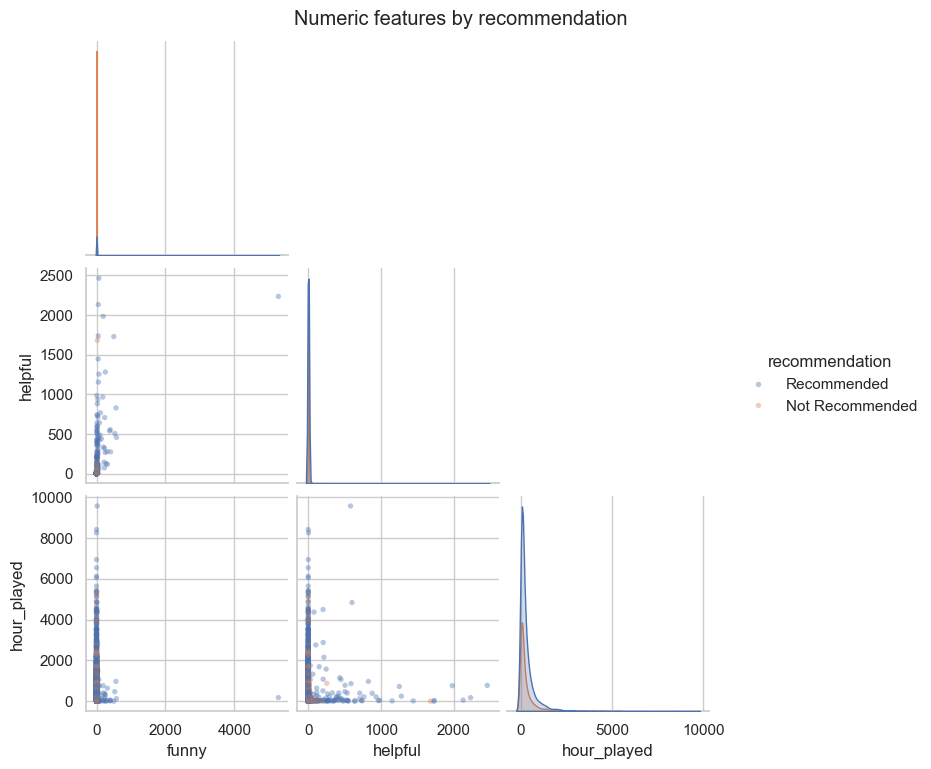

In [10]:
# Pairwise relationships of the numeric features, coloured by the target
features = ['funny', 'helpful', 'hour_played']
g = sns.pairplot(
    df_clean[features + ['recommendation']],
    hue='recommendation',
    diag_kind='kde',
    plot_kws={'alpha': 0.4, 's': 15, 'edgecolor': 'none'},
    corner=True,
)
g.fig.suptitle('Numeric features by recommendation', y=1.02)
plt.show()

count    14610.0
mean       296.1
std        510.1
min          0.0
25%         33.2
50%        122.0
75%        340.0
max       9567.0
Name: hour_played, dtype: float64


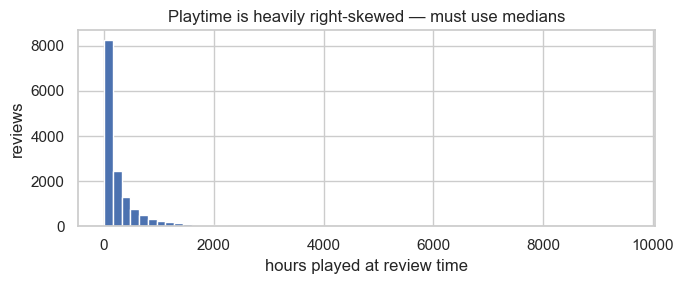

In [ ]:
print(df_clean["hour_played"].describe().round(1))

fig, ax = plt.subplots(figsize=(7,3))
df_clean["hour_played"].hist(bins=60, ax=ax)
ax.set_xlabel("hours played at review time")
ax.set_ylabel("reviews")
ax.set_title("Playtime is heavily right-skewed")
plt.tight_layout()
plt.show()

## Insight 1 — lifetime averages hide sentiment crashes

MONSTER HUNTER: WORLD: lifetime 60% positive | worst quarter 2018-07-01 at 52% (n=479)
Rocket League: lifetime 61% positive | worst quarter 2018-07-01 at 37% (n=108)
Dead by Daylight: lifetime 63% positive | worst quarter 2016-07-01 at 53% (n=127)
Grand Theft Auto V: lifetime 63% positive | worst quarter 2017-04-01 at 24% (n=577)
The Elder Scrolls V: Skyrim Special Edition: lifetime 64% positive | worst quarter 2017-07-01 at 36% (n=73)
Rust: lifetime 66% positive | worst quarter 2019-01-01 at 53% (n=47)
PLAYERUNKNOWN'S BATTLEGROUNDS: lifetime 68% positive | worst quarter 2018-07-01 at 48% (n=166)
ASTRONEER: lifetime 86% positive | worst quarter 2018-07-01 at 81% (n=42)
Insurgency: Sandstorm: lifetime 94% positive | worst quarter 2018-10-01 at 93% (n=138)
RESIDENT EVIL 2 / BIOHAZARD RE:2: lifetime 99% positive | worst quarter 2019-01-01 at 99% (n=496)
Slay the Spire: lifetime 99% positive | worst quarter 2018-10-01 at 100% (n=205)
Left 4 Dead 2: lifetime 100% positive | worst quarter 20

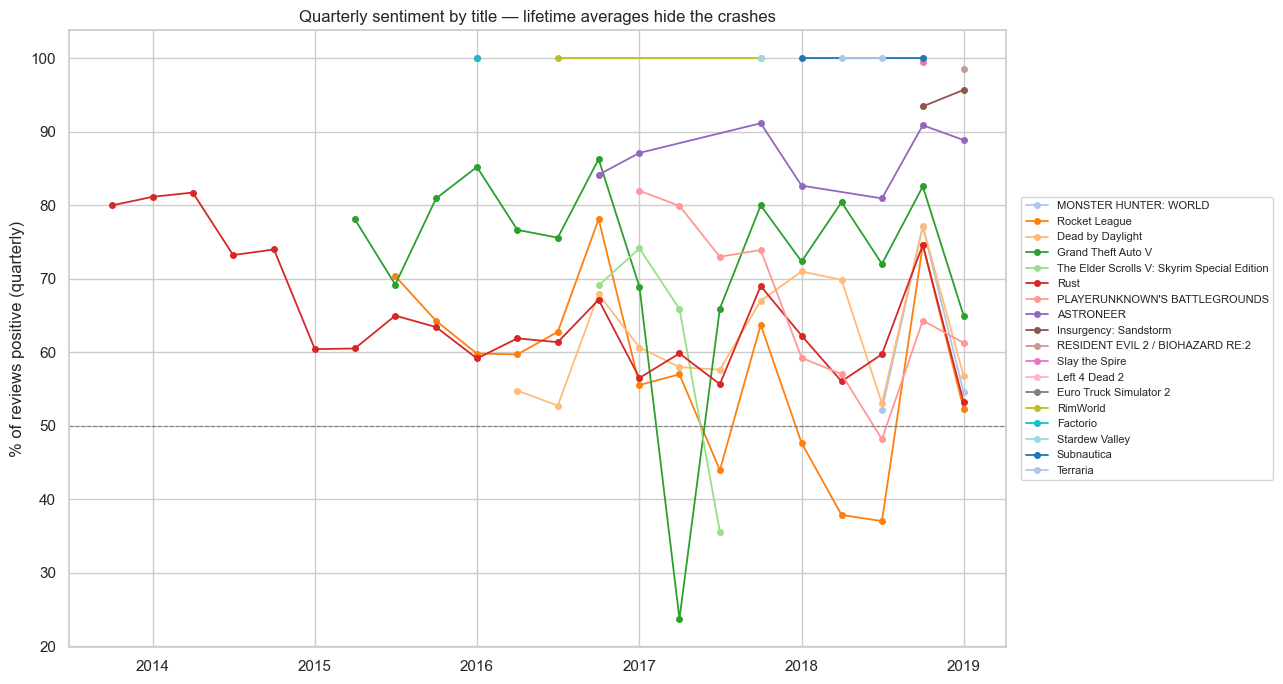

In [31]:
d = df_clean.copy()
d['rec'] = (d['recommendation'] == 'Recommended').astype(int)

# order titles by lifetime sentiment so the legend reads worst -> best
order = d.groupby('title')['rec'].mean().sort_values().index
cmap = plt.colormaps['tab20']

fig, ax = plt.subplots(figsize=(13, 7))
for i, t in enumerate(order):
    g = d[d['title'] == t].set_index('date_posted').sort_index()
    q = g['rec'].resample('QS').agg(['mean', 'count'])
    q = q[q['count'] >= 30]          # only quarters with enough reviews to trust
    if q.empty:                      # thin_coverage titles never clear the bar
        continue
    ax.plot(q.index, q['mean'] * 100, marker='o', ms=4, lw=1.3,
            label=t, color=cmap(i % 20))
    worst = q['mean'].idxmin()
    print(f"{t}: lifetime {g['rec'].mean():.0%} positive | worst quarter {worst.date()} "
          f"at {q.loc[worst, 'mean']:.0%} (n={int(q.loc[worst, 'count'])})")

ax.axhline(50, color='grey', lw=0.8, ls='--')
ax.set_ylabel('% of reviews positive (quarterly)')
ax.set_title('Quarterly sentiment by title — lifetime averages hide the crashes')
ax.legend(loc='center left', bbox_to_anchor=(1.01, 0.5), fontsize=8, ncol=1)
plt.tight_layout()
plt.savefig('../outputs/insight_1_sentiment_all_games.png', dpi=150, bbox_inches='tight')
plt.show()


Grand Theft Auto V: lifetime 63% positive | worst quarter 2017-04-01 at 24% (n=577)
PLAYERUNKNOWN'S BATTLEGROUNDS: lifetime 68% positive | worst quarter 2018-07-01 at 48% (n=166)


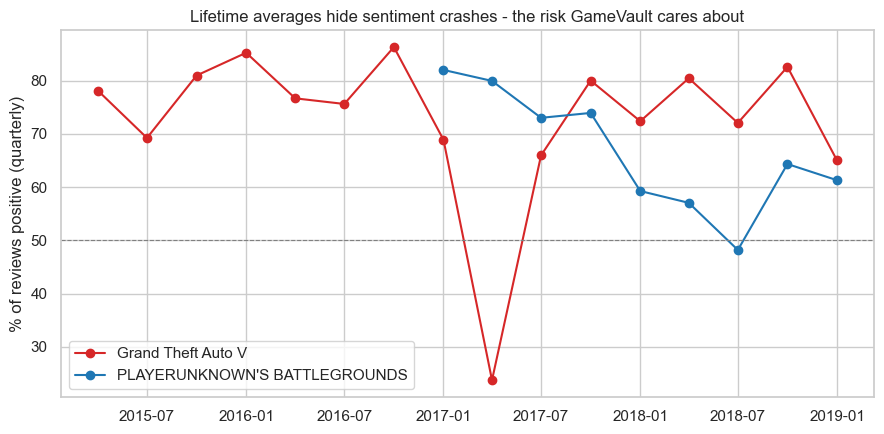

In [32]:
d = df_clean.copy()
d['rec'] = (d['recommendation'] == 'Recommended').astype(int)

fig, ax = plt.subplots(figsize=(9, 4.5))
for t, color in [('Grand Theft Auto V', '#d62728'), ("PLAYERUNKNOWN'S BATTLEGROUNDS", '#1f77b4')]:
    g = d[d['title'] == t].set_index('date_posted').sort_index()
    q = g['rec'].resample('QS').agg(['mean', 'count'])
    q = q[q['count'] >= 30]          # only quarters with enough reviews to trust
    ax.plot(q.index, q['mean'] * 100, marker='o', label=t, color=color)
    worst = q['mean'].idxmin()
    print(f"{t}: lifetime {g['rec'].mean():.0%} positive | worst quarter {worst.date()} "
          f"at {q.loc[worst, 'mean']:.0%} (n={int(q.loc[worst, 'count'])})")
ax.axhline(50, color='grey', lw=0.8, ls='--')
ax.set_ylabel('% of reviews positive (quarterly)')
ax.set_title('Lifetime averages hide sentiment crashes - the risk GameVault cares about')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/insight_1_sentiment_crashes.png', dpi=150)
plt.show()

## Insight 2 — Hours played predicts recommendation

             pct_positive     n
hour_played                    
<10h                0.471  1605
10-50h              0.736  2936
50-200h             0.743  4499
200-1000h           0.740  4588
1000h+              0.745   982

Median hours played: {'Not Recommended': 95.0, 'Recommended': 133.0}


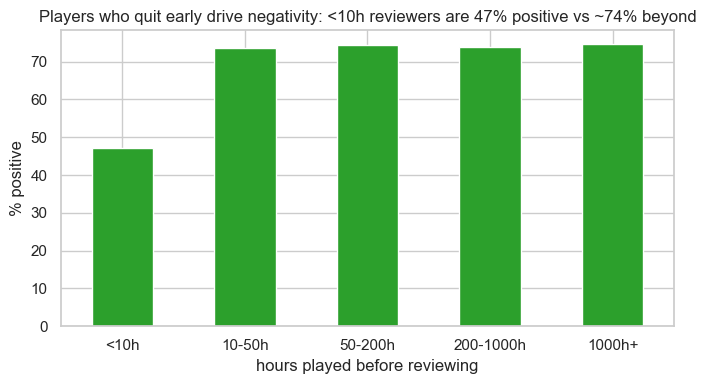

In [33]:
buckets = pd.cut(d['hour_played'], [0, 10, 50, 200, 1000, 20000], right=False,
                 labels=['<10h', '10-50h', '50-200h', '200-1000h', '1000h+'])
by_bucket = d.groupby(buckets, observed=True)['rec'].agg(pct_positive='mean', n='count')
print(by_bucket.round(3))
print()
print('Median hours played:', d.groupby('recommendation')['hour_played'].median().to_dict())

ax = (by_bucket['pct_positive'] * 100).plot(kind='bar', figsize=(7, 4), color='#2ca02c', rot=0)
ax.set_ylabel('% positive')
ax.set_xlabel('hours played before reviewing')
ax.set_title('Players who quit early drive negativity: <10h reviewers are 47% positive vs ~74% beyond')
plt.tight_layout()
plt.savefig('../outputs/insight_2_engagement.png', dpi=150)
plt.show()

### Since some games have less than 10 reviews and is recently released we should not include them in the model since we are operating at a low risk tolerance

In [29]:
ref_date = df_clean["date_posted"].max()   # dataset ends 2019-02; 'recent' must anchor here, not today

games = (df_clean.groupby("title")
           .agg(n_reviews=("review", "size"),
                first_review=("date_posted", "min"),
                last_review=("date_posted", "max"),
                pct_recommended=("recommendation", lambda s: s.eq("Recommended").mean()),
                median_hours=("hour_played", "median")))
games["history_days"] = (games["last_review"] - games["first_review"]).dt.days

MIN_REVIEWS = 100
MIN_HISTORY_DAYS = 180

games["bucket"] = "scored"
games.loc[games["history_days"] < MIN_HISTORY_DAYS, "bucket"] = "hot launch - durability unverified"
games.loc[games["n_reviews"] < MIN_REVIEWS, "bucket"] = "insufficient data"

games.sort_values("n_reviews", ascending=False).round({"pct_recommended": 2, "median_hours": 1})

,n_reviews,first_review,last_review,pct_recommended,median_hours,history_days,bucket
title,,,,,,,
PLAYERUNKNOWN'S BATTLEGROUNDS,2538,2017-03-23,2019-02-13,0.68,234.0,692,scored
Rust,2290,2013-12-11,2019-02-10,0.66,171.0,1887,scored
Grand Theft Auto V,2173,2015-04-13,2019-02-16,0.63,182.0,1405,scored
Rocket League,1772,2015-07-07,2019-02-13,0.61,164.5,1317,scored
Dead by Daylight,1034,2016-06-14,2019-02-09,0.63,97.0,970,scored
The Elder Scrolls V: Skyrim Special Edition,976,2016-10-27,2019-02-02,0.64,46.5,828,scored
MONSTER HUNTER: WORLD,774,2018-08-09,2019-02-16,0.60,107.0,191,scored
ASTRONEER,576,2016-12-15,2019-02-13,0.86,28.0,790,scored
RESIDENT EVIL 2 / BIOHAZARD RE:2,496,2019-01-24,2019-02-16,0.99,21.0,23,hot launch - durability unverified


In [ ]:
import os
os.makedirs('../outputs', exist_ok=True)
# CSV (not parquet) hand-off: parquet would need pyarrow, which is not in the pinned dependency list
df_clean.to_csv('../outputs/df_clean.csv', index=False)
print('Saved ../outputs/df_clean.csv', df_clean.shape)